In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

shared_folder_path = '/content/drive/MyDrive/semeval'

# Cek apakah folder bisa diakses
os.listdir(shared_folder_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['public_data_test',
 'public_data_dev',
 'saved_model',
 '.ipynb_checkpoints',
 'for_eval',
 'model_b4aug',
 'model_aug']

In [ ]:
!pip install datasets

### Text Augmentation

In [ ]:
import datasets
from datasets import load_dataset, concatenate_datasets

arabic_data = load_dataset("SemEvalWorkshop/sem_eval_2018_task_1", 'subtask5.arabic')
english_data = load_dataset("SemEvalWorkshop/sem_eval_2018_task_1", 'subtask5.english')
spanish_data = load_dataset("SemEvalWorkshop/sem_eval_2018_task_1", 'subtask5.spanish')

In [ ]:
arabic_combined = concatenate_datasets([arabic_data['train'], arabic_data['validation']])
english_combined = concatenate_datasets([english_data['train'], english_data['validation']])
spanish_combined = concatenate_datasets([spanish_data['train'], spanish_data['validation']])

In [ ]:
import pandas as pd
from datasets import concatenate_datasets

# Konversi ke DataFrame dan tambahkan kolom bahasa
arabic_df = pd.DataFrame(data=arabic_combined)
arabic_df["language"] = "arq"

english_df = pd.DataFrame(data=english_combined)
english_df["language"] = "eng"

spanish_df = pd.DataFrame(data=spanish_combined)
spanish_df["language"] = "esp"

In [ ]:
aug_df = pd.concat([arabic_df, english_df, spanish_df], ignore_index=True)

In [ ]:
aug_df

,ID,Tweet,anger,anticipation,disgust,fear,joy,love,optimism,pessimism,sadness,surprise,trust,language
0,2018-Ar-00259,ظلينا نتكلم ساعات ساعات رتبت فيها نفسي وبكيت ف...,True,False,False,True,False,False,False,True,True,False,False,arq
1,2018-Ar-02696,كل سنه وانتي بخير ياقلبي وكل سنه وانتي سعيده ي...,False,False,False,False,True,True,True,False,False,False,False,arq
2,2018-Ar-03596,البسطاء يمتلكون أرواح نادره جداتجدهم بمظهر متو...,False,False,False,False,False,True,True,False,False,False,False,arq
3,2018-Ar-02999,مومعقول اللي قاعد يصير فيني هالايام يارب ماينت...,False,False,False,True,False,False,False,False,False,False,False,arq
4,2018-Ar-02716,انا اكثر شخص متناقض بداخلي حب وكره وامل وقنوط ...,True,False,False,False,False,False,False,False,True,False,False,arq
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14822,2018-Es-06551,@tccharless -Peligro al volante -Tec -Los San...,False,False,False,True,False,False,False,False,False,False,False,esp
14823,2018-Es-02782,Vamos a ver q sucedio en mi barrio en los 90 #...,False,True,False,False,False,False,False,False,False,False,False,esp
14824,2018-Es-01308,@kopexinfinity FELICIDADES FER 💕 QUE ESTA PASA...,False,False,False,False,True,False,False,False,False,False,False,esp
14825,2018-Es-02136,@PabloEmanuel299 LAMENTO MI CONFUSIÓN DE RAMA ...,False,False,False,False,False,False,False,False,False,False,False,esp


In [ ]:
columns_to_keep = ['Tweet', 'anger', 'fear', 'joy', 'sadness', 'surprise', 'disgust', 'language']
aug_df = aug_df[columns_to_keep]

aug_df.rename(columns={'Tweet': 'text'}, inplace=True)

for col in ['anger', 'fear', 'joy', 'sadness', 'surprise', 'disgust']:
    aug_df[col] = aug_df[col].astype(int)

<ipython-input-86-c570d4f38261>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aug_df.rename(columns={'Tweet': 'text'}, inplace=True)
<ipython-input-86-c570d4f38261>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  aug_df[col] = aug_df[col].astype(int)
<ipython-input-86-c570d4f38261>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versu

In [ ]:
aug_df.head()

,text,anger,fear,joy,sadness,surprise,disgust,language
0,ظلينا نتكلم ساعات ساعات رتبت فيها نفسي وبكيت ف...,1,1,0,1,0,0,arq
1,كل سنه وانتي بخير ياقلبي وكل سنه وانتي سعيده ي...,0,0,1,0,0,0,arq
2,البسطاء يمتلكون أرواح نادره جداتجدهم بمظهر متو...,0,0,0,0,0,0,arq
3,مومعقول اللي قاعد يصير فيني هالايام يارب ماينت...,0,1,0,0,0,0,arq
4,انا اكثر شخص متناقض بداخلي حب وكره وامل وقنوط ...,1,0,0,1,0,0,arq


### Load Dataset

In [ ]:
import os

folder_path = "drive/MyDrive/semeval/public_data_test/track_a/train"
dataframes = []

for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df.columns = [col.lower() for col in df.columns]

        # Ambil nama file tanpa ekstensi sebagai bahasa
        language = file.replace(".csv", "")
        df["language"] = language  # Tambahkan kolom bahasa

        cols = [col for col in df.columns if col != "language"] + ["language"]
        df = df.reindex(columns=cols)

        dataframes.append(df)

combined_df = pd.concat(dataframes, ignore_index=True)

for col in ['anger', 'fear', 'joy', 'sadness', 'surprise', 'disgust']:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce').fillna(0).astype(int)

df = combined_df.iloc[:, 1:]


In [ ]:
# import os
# import pandas as pd

# folder_path = "drive/MyDrive/semeval/public_data_test/track_a/train"
# dataframes = []

# # Daftar kolom wajib tanpa 'text' dan 'language'
# required_columns = ['anger', 'fear', 'joy', 'sadness', 'surprise', 'disgust']

# for file in os.listdir(folder_path):
#     if file.endswith(".csv"):
#         file_path = os.path.join(folder_path, file)
#         df = pd.read_csv(file_path)
#         df.columns = [col.lower() for col in df.columns]

#         # Ambil nama file sebagai bahasa
#         language = file.replace(".csv", "")
#         df["language"] = language  # Tambahkan kolom bahasa

#         # Pastikan semua kolom wajib ada (jika tidak ada, tambahkan dengan 0)
#         for col in required_columns:
#             if col not in df.columns:
#                 df[col] = 0  # Default ke 0 jika kolom tidak ada

#         # Susun ulang agar 'text' tetap di awal, 'language' di akhir, dan emosi di tengah
#         ordered_cols = ['text'] + required_columns + ['language']
#         df = df[ordered_cols]

#         dataframes.append(df)

# # Gabungkan semua dataframe
# combined_df = pd.concat(dataframes, ignore_index=True)

# # Konversi kolom emosi ke integer untuk memastikan format konsisten
# for col in required_columns:
#     combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce').fillna(0).astype(int)

# # Cek hasil
# print(combined_df.head())
# print(combined_df.columns)  # Pastikan urutan kolom sudah benar


In [ ]:
# import os
# import pandas as pd

# train_folder_path = "drive/MyDrive/semeval/public_data_test/track_a/train"
# dev_folder_path = "drive/MyDrive/semeval/public_data_test/track_a/dev"

# def load_and_process_folder(folder_path):
#     dataframes = []
#     for file in os.listdir(folder_path):
#         if file.endswith(".csv"):
#             file_path = os.path.join(folder_path, file)
#             df = pd.read_csv(file_path)
#             df.columns = [col.lower() for col in df.columns]
#             sampled_df = df.sample(frac=0.2, random_state=42)
#             dataframes.append(sampled_df)
#     combined_df = pd.concat(dataframes, ignore_index=True)
#     if len(combined_df.columns) >= 6:
#         for col in combined_df.columns[-6:]:
#             combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce').fillna(0).astype(int)
#     return combined_df

# train_df = load_and_process_folder(train_folder_path)
# dev_df = load_and_process_folder(dev_folder_path)

# combined_df = pd.concat([train_df, dev_df], ignore_index=True)

# # df = combined_df.iloc[:, 1:]
# df = combined_df.copy()

In [ ]:
df

,text,anger,fear,joy,sadness,surprise,language,disgust
0,"Colorado, middle of nowhere.",0,1,0,0,1,eng,0
1,This involved swimming a pretty large lake tha...,0,1,0,0,0,eng,0
2,It was one of my most shameful experiences.,0,1,0,1,0,eng,0
3,"After all, I had vegetables coming out my ears...",0,0,0,0,0,eng,0
4,Then the screaming started.,0,1,0,1,1,eng,0
...,...,...,...,...,...,...,...,...
65093,Minunat profund și simplu Mulțumim pentru lumi...,0,0,1,0,0,ron,0
65094,ma bucur foarte mult sa aflu aceasta,0,0,1,0,1,ron,0
65095,Este o emisiune foarte interesantă O ascult cu...,0,0,1,0,0,ron,0
65096,Retelele 5G au un EFECT DEVASTATOR AVERTIZARE ...,0,1,0,0,0,ron,0


In [ ]:
df = df[[col for col in df.columns if col != "language"] + ["language"]]

In [ ]:
df

,text,anger,fear,joy,sadness,surprise,disgust,language
0,"Colorado, middle of nowhere.",0,1,0,0,1,0,eng
1,This involved swimming a pretty large lake tha...,0,1,0,0,0,0,eng
2,It was one of my most shameful experiences.,0,1,0,1,0,0,eng
3,"After all, I had vegetables coming out my ears...",0,0,0,0,0,0,eng
4,Then the screaming started.,0,1,0,1,1,0,eng
...,...,...,...,...,...,...,...,...
65093,Minunat profund și simplu Mulțumim pentru lumi...,0,0,1,0,0,0,ron
65094,ma bucur foarte mult sa aflu aceasta,0,0,1,0,1,0,ron
65095,Este o emisiune foarte interesantă O ascult cu...,0,0,1,0,0,0,ron
65096,Retelele 5G au un EFECT DEVASTATOR AVERTIZARE ...,0,1,0,0,0,0,ron


In [ ]:
# Combine df with aug_df
full_df = pd.concat([df, aug_df], ignore_index=True)

In [ ]:
ID2LABEL = {}
LABEL2ID = {}

for idx,label in enumerate(df.columns):
    if label in ['text'] or label in ['id'] or label in ['language']:
        continue

    ID2LABEL[idx-1] = label
    LABEL2ID[label] = idx-1

print(f"ID2LABEL: {ID2LABEL}")
print(f"LABEL2ID: {LABEL2ID}")

ID2LABEL: {0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness', 4: 'surprise', 5: 'disgust'}
LABEL2ID: {'anger': 0, 'fear': 1, 'joy': 2, 'sadness': 3, 'surprise': 4, 'disgust': 5}


In [ ]:
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict

# X = df['text']
# y = df.drop('text', axis=1)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
stratify_cols = ['anger', 'fear', 'joy', 'sadness', 'surprise', 'disgust', 'language']
train_df, test_df = train_test_split(full_df, test_size=0.2, random_state=42)

# Step 2: Cek distribusi data sebelum stratifikasi
category_counts = train_df.groupby(stratify_cols).size()
min_count = category_counts.min()

print(f"Jumlah sampel minimum dalam kategori stratifikasi: {min_count}")

# Step 3: Jika ada kategori dengan hanya 1 sampel, gunakan stratifikasi pada subset yang lebih luas
if min_count < 2:
    print("Menggunakan stratifikasi hanya pada 'language' untuk menghindari error.")
    stratify_cols = ['language']

train_stratified_df, _ = train_test_split(
    train_df, test_size=0.9, stratify=train_df[stratify_cols], random_state=42
)

train_dataset = Dataset.from_pandas(train_stratified_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))

# Combine them into a DatasetDict
dataset_dict = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

# Print information about the DatasetDict
print(dataset_dict)

Jumlah sampel minimum dalam kategori stratifikasi: 1
Menggunakan stratifikasi hanya pada 'language' untuk menghindari error.
DatasetDict({
    train: Dataset({
        features: ['text', 'anger', 'fear', 'joy', 'sadness', 'surprise', 'disgust', 'language'],
        num_rows: 6394
    })
    test: Dataset({
        features: ['text', 'anger', 'fear', 'joy', 'sadness', 'surprise', 'disgust', 'language'],
        num_rows: 15985
    })
})


In [ ]:
print(train_df["language"].value_counts(normalize=True))

language
eng     0.131608
esp     0.077995
arq     0.047154
tir     0.046387
pcm     0.046293
amh     0.044307
orm     0.043291
som     0.042806
swa     0.041148
yor     0.037426
ibo     0.036237
chn     0.032984
rus     0.032953
hin     0.032218
deu     0.032202
ukr     0.030810
kin     0.030419
mar     0.030419
ptbr    0.027932
hau     0.026963
ary     0.020222
ptmz    0.019503
vmw     0.018783
afr     0.015655
ron     0.015030
swe     0.014873
tat     0.012699
sun     0.011683
Name: proportion, dtype: float64


In [ ]:
print(train_stratified_df["language"].value_counts(normalize=True))  # Cek distribusi bahasa
# print(train_stratified_df.iloc[:, 1:].sum())

language
eng     0.131686
esp     0.078042
arq     0.047075
tir     0.046450
pcm     0.046293
amh     0.044260
orm     0.043322
som     0.042853
swa     0.041132
yor     0.037379
ibo     0.036284
chn     0.033000
rus     0.033000
deu     0.032218
hin     0.032218
ukr     0.030810
kin     0.030341
mar     0.030341
ptbr    0.027995
hau     0.026900
ary     0.020175
ptmz    0.019550
vmw     0.018768
afr     0.015640
ron     0.015014
swe     0.014858
tat     0.012668
sun     0.011730
Name: proportion, dtype: float64


In [ ]:
# get emotion counts by split type
split_types = list(dataset_dict.keys())
emotion_split_counts = {}

for label in LABEL2ID:
    for split_type in split_types:
        if label not in emotion_split_counts:
            emotion_split_counts[label] = []
        emotion_split_counts[label].append(sum(dataset_dict[split_type][label]))

print(f"SPLIT_TYPES: {split_types}")
print(f"EMOTION_SPLIT_COUNTS: {emotion_split_counts}")

SPLIT_TYPES: ['train', 'test']
EMOTION_SPLIT_COUNTS: {'anger': [1373, 3298], 'fear': [702, 1790], 'joy': [1459, 3669], 'sadness': [1320, 3355], 'surprise': [620, 1660], 'disgust': [1210, 2995]}


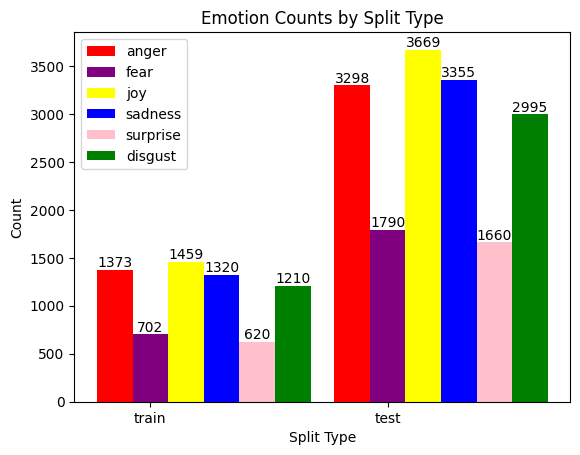

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

LABEL2COLOR = {
    'anger': 'red',
    'disgust': 'green',
    'fear':'purple',
    'joy': 'yellow',
    'sadness': 'blue',
    'surprise': 'pink',
}

x = np.arange(len(split_types))
width = 0.15
multiplier = 0

fig, ax = plt.subplots()
for label, counts in emotion_split_counts.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, counts, width, label=label, color=LABEL2COLOR[label])
    ax.bar_label(rects, label_type='edge')
    multiplier += 1

ax.set_xlabel('Split Type')
ax.set_ylabel('Count')
ax.set_title('Emotion Counts by Split Type')
ax.set_xticks(x + width, split_types)
ax.legend()
plt.show()

In [ ]:
emotion_counts = {}
for label in LABEL2ID:
    for split_type in dataset_dict.keys():
        emotion_counts[label] = emotion_counts.get(label,0)+sum(dataset_dict[split_type][label])

print(f"EMOTION_COUNTS: {emotion_counts}")

EMOTION_COUNTS: {'anger': 4671, 'fear': 2492, 'joy': 5128, 'sadness': 4675, 'surprise': 2280, 'disgust': 4205}


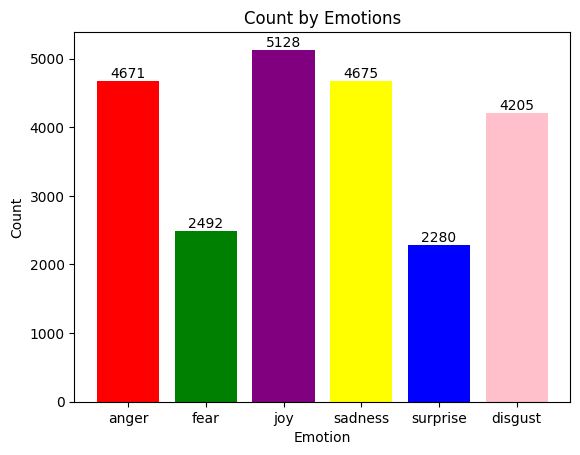

In [ ]:
# plot bar graph with total emotion counts
fig, ax = plt.subplots()
bar_container = ax.bar(emotion_counts.keys(), emotion_counts.values(), color=LABEL2COLOR.values())
ax.bar_label(bar_container, label_type='edge')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.set_title('Count by Emotions')
plt.show()

# Preprocessing

In [ ]:
def preprocess(batch):
    # rename column
    # batch['ID'] = batch['id']
    batch['Tweet'] = batch['text']

    # get one-hot encoded labels for each example in batch
    # for example: anger and sadness = vector of [1,0,0,0,1]
    batch['labels'] = [[float(batch[label][i]) for label in LABEL2ID] for i in range(len(batch['Tweet']))]
    return batch

preprocessed_datasets = dataset_dict.map(preprocess, batched=True, remove_columns=dataset_dict['train'].column_names)
preprocessed_datasets

Map:   0%|          | 0/6394 [00:00<?, ? examples/s]

Map:   0%|          | 0/15985 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Tweet', 'labels'],
        num_rows: 6394
    })
    test: Dataset({
        features: ['Tweet', 'labels'],
        num_rows: 15985
    })
})

In [ ]:
preprocessed_datasets['train'][2]

{'Tweet': "Namuu bakka jirutti waan humnasaatiin dhiibbaa uumuu danda’u qaba . Miidiyaaleen sabaahimaa Miidiyaaleen hawaasaa dhimma hidhamtoota Siyaasa Oromoo irra deddeebiin dubbachuu qabu . Erga rakkoon dhalatee bo'uurra dursinee yaaduun gaarii natti fakkaata . Lalisa Indiris Adam URL",
 'labels': [1.0, 0.0, 0.0, 0.0, 0.0, 0.0]}

# Data Tokenization

In [ ]:
from transformers import AutoTokenizer

CHECKPOINT = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)
tokenizer

XLMRobertaTokenizerFast(name_or_path='xlm-roberta-base', vocab_size=250002, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<pad>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	250001: AddedToken("<mask>", rstrip=False, lstrip=True, single_word=False, normalized=False, special=True),
}
)

In [ ]:
# tokenize out datasets with truncation
tokenized_datasets = preprocessed_datasets.map(lambda batch: tokenizer(batch['Tweet'], padding="max_length", truncation=True, max_length=512), batched=True, remove_columns=['Tweet'])
tokenized_datasets

Map:   0%|          | 0/6394 [00:00<?, ? examples/s]

Map:   0%|          | 0/15985 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 6394
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'attention_mask'],
        num_rows: 15985
    })
})

In [ ]:
tokenized_datasets['train'][:1]

{'labels': [[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]],
 'input_ids': [[0,
   1519,
   1491,
   763,
   38,
   139808,
   38,
   35173,
   12340,
   38,
   22221,
   372,
   15296,
   6,
   872,
   1177,
   12340,
   6121,
   31,
   362,
   4542,
   38,
   67371,
   77973,
   3613,
   1436,
   38,
   13274,
   7933,
   50985,
   34,
   12340,
   38,
   6,
   232773,
   232773,
   232773,
   232773,
   173894,
   95538,
   4904,
   4904,
   2,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,


# Model Training

In [ ]:
# set seed for reproducibility
import torch

SEED = 42
torch.manual_seed(SEED)

In [ ]:
# let's clone a model and finetune as a multi-label classification problem
from transformers import AutoModelForSequenceClassification

# source: https://huggingface.co/distilbert-base-uncased
model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, problem_type='multi_label_classification', num_labels=len(LABEL2ID), id2label=ID2LABEL, label2id=LABEL2ID)
# model = AutoModelForSequenceClassification.from_pretrained("drive/MyDrive/semeval/saved_model")


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
model = model.to(device)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# this function calculates accuracy per label in a prediction instead of per prediction
def samples_accuracy_score(y_true, y_pred):
    return np.sum(y_true==y_pred) / y_true.size

def compute_metrics(eval_preds):
    logits, labels = eval_preds
    # we sigmoid all logits for multilabel metrics
    predictions = torch.nn.functional.sigmoid(torch.Tensor(logits))
    # we set threshold to 0.50 to classify positive >= 0.50 and negative < 0.50
    predictions = (predictions >= 0.50).int().numpy()
    # overall accuracy measures accuracy of each true label list and prediction list
    overall_accuracy = accuracy_score(labels, predictions)
    # sample accuracy measures accuracy of each true label in a true label list and prediction in prediction list
    samples_accuracy = samples_accuracy_score(labels, predictions)
    # overall f1 measures macro f1 of each true label list and prediction list, ignoring zero division warnings
    overall_f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    # samples f1 measures f1 of each true label in a true label list and prediction in prediction list, ignoring zero division warnings
    samples_f1 = f1_score(labels, predictions, average='samples', zero_division=0)
    return {
        'overall_accuracy': overall_accuracy,
        'samples_accuracy': samples_accuracy,
        'overall_f1': overall_f1,
        'samples_f1': samples_f1,
    }

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    seed=SEED,                          # seed for reproducibility
    output_dir='results',               # output directory to store epoch checkpoints
    num_train_epochs=5,                 # number of training epochs
    optim='adamw_torch',                # default optimizer as AdamW
    per_device_train_batch_size=32,     # 32 train batch size to speed up training
    per_device_eval_batch_size=32,      # 32 eval batch size to speed up evaluation
    evaluation_strategy='epoch',        # set evaluation strategy to each epoch instead of default 500 steps
    save_strategy='epoch',              # set saving of model strategy to each epoch instead of default 500 steps
    load_best_model_at_end=True,        # load the best model with lowest validation loss
    report_to='none',                   # suppress third-party logging
)

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['test'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

<ipython-input-114-878777cbfc94>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
# let's see what an unfine-tuned bert can do
trainer.evaluate(tokenized_datasets['test'])

{'eval_loss': 0.6944543719291687,
 'eval_model_preparation_time': 0.0114,
 'eval_overall_accuracy': 0.00012511729746637472,
 'eval_samples_accuracy': 0.49103326034824313,
 'eval_overall_f1': 0.16693745271700858,
 'eval_samples_f1': 0.24368321491874825,
 'eval_runtime': 429.3775,
 'eval_samples_per_second': 37.228,
 'eval_steps_per_second': 1.164}

In [ ]:
# let's fine-tune bert as a multilabel problem
trainer.train()

Epoch,Training Loss,Validation Loss,Model Preparation Time,Overall Accuracy,Samples Accuracy,Overall F1,Samples F1
1,No log,0.435876,0.011400,0.252987,0.825858,0.055350,0.051628
2,No log,0.381060,0.011400,0.332061,0.848108,0.284969,0.196684
3,0.414800,0.362372,0.011400,0.378918,0.856741,0.409174,0.293278
4,0.414800,0.359229,0.011400,0.395371,0.857387,0.439807,0.324107
5,0.308900,0.355910,0.011400,0.405818,0.859483,0.469025,0.345892


TrainOutput(global_step=1000, training_loss=0.3618313293457031, metrics={'train_runtime': 5378.1094, 'train_samples_per_second': 5.944, 'train_steps_per_second': 0.186, 'total_flos': 8411962539479040.0, 'train_loss': 0.3618313293457031, 'epoch': 5.0})

In [ ]:
# let's see what a finetuned bert can do
trainer.evaluate(tokenized_datasets['test'])

{'eval_loss': 0.3559102416038513,
 'eval_model_preparation_time': 0.0114,
 'eval_overall_accuracy': 0.4058179543321864,
 'eval_samples_accuracy': 0.8594828485038056,
 'eval_overall_f1': 0.46902479547079107,
 'eval_samples_f1': 0.3458919820665207,
 'eval_runtime': 436.911,
 'eval_samples_per_second': 36.586,
 'eval_steps_per_second': 1.144,
 'epoch': 5.0}

In [ ]:
predictions, label_ids, metrics = trainer.predict(tokenized_datasets['test'])

In [ ]:
sigmoid = torch.sigmoid(torch.tensor(predictions))

In [ ]:
predicted_labels = sigmoid.numpy()

In [ ]:
threshold = 0.5
predicted_labels_binary = (predicted_labels > threshold).astype(int)

In [ ]:
for idx, (pred, true_label) in enumerate(zip(predicted_labels_binary, label_ids)):
    print(f"Row {idx}: Predicted labels = {pred}, True labels = {true_label}")

Streaming output truncated to the last 5000 lines.
Row 10985: Predicted labels = [0 0 1 0 0 0], True labels = [0. 0. 1. 0. 0. 0.]
Row 10986: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 0. 0. 1. 0.]
Row 10987: Predicted labels = [0 0 0 1 0 0], True labels = [0. 0. 0. 1. 0. 0.]
Row 10988: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 0. 0. 1. 0.]
Row 10989: Predicted labels = [0 0 0 0 0 0], True labels = [1. 0. 0. 0. 0. 0.]
Row 10990: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 0. 1. 0. 0.]
Row 10991: Predicted labels = [1 0 0 0 0 1], True labels = [0. 0. 0. 0. 0. 1.]
Row 10992: Predicted labels = [0 0 1 0 0 0], True labels = [0. 0. 1. 0. 0. 0.]
Row 10993: Predicted labels = [1 0 0 0 0 1], True labels = [1. 0. 0. 1. 0. 1.]
Row 10994: Predicted labels = [1 0 0 0 0 0], True labels = [1. 0. 0. 0. 0. 0.]
Row 10995: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 1. 0. 0. 0.]
Row 10996: Predicted labels = [0 0 0 0 0 0], True labels = [0. 0. 0. 0. 0. 0.]
R

In [ ]:
trainer.save_model("drive/MyDrive/semeval/model_aug")
# tokenizer.save_pretrained("drive/MyDrive/semeval/saved_model")

In [ ]:
# import os
# import pandas as pd


# "

# # Menentukan folder tujuan untuk prediksi dan true labels
# pred_folder = "drive/MyDrive/semeval/for_eval/pred"
# true_folder = "drive/MyDrive/semeval/for_eval/true"

# # Pastikan folder sudah ada, jika belum maka buat folder tersebut
# os.makedirs(pred_folder, exist_ok=True)
# os.makedirs(true_folder, exist_ok=True)

# # Dictionary untuk menyimpan DataFrame berdasarkan bahasa
# predictions_by_language = {}
# true_labels_by_language = {}

# # Definisikan label kelas yang sesuai
# labels = ['anger', 'fear', 'joy', 'sadness', 'surprise', 'disgust']

# # Proses prediksi dan true labels per bahasa
# for idx, sample in enumerate(tokenized_datasets['test']):
#     # Ekstrak ID dan bahasa dari ID
#     sample_id = sample['ID']
#     language = sample_id.split('_')[0]  # Mengambil bagian pertama dari ID sebagai kode bahasa, misalnya 'orm'

#     # Menghitung sigmoid untuk mendapatkan prediksi probabilitas
#     sigmoid = torch.sigmoid(torch.tensor(predictions[idx]))
#     predicted_labels = sigmoid.numpy()

#     # Mengonversi prediksi probabilitas ke biner berdasarkan threshold
#     predicted_labels_binary = (predicted_labels > threshold).astype(int)

#     # Jika bahasa belum ada dalam dictionary, inisialisasi DataFrame untuk bahasa tersebut
#     if language not in predictions_by_language:
#         predictions_by_language[language] = {'id': [], 'pred': []}
#         true_labels_by_language[language] = {'id': [], 'true': []}

#     # Menambahkan hasil prediksi dan true label ke dalam list untuk bahasa yang sesuai
#     predictions_by_language[language]['id'].append(sample_id)
#     predictions_by_language[language]['pred'].append(predicted_labels_binary)
#     true_labels_by_language[language]['id'].append(sample_id)
#     true_labels_by_language[language]['true'].append(label_ids[idx])

# # Menyimpan data per bahasa ke file CSV
# for language in predictions_by_language:
#     # Menggabungkan ID dengan prediksi untuk bahasa tertentu
#     predictions_data = predictions_by_language[language]
#     true_labels_data = true_labels_by_language[language]

#     # Membuat DataFrame untuk prediksi
#     predictions_df = pd.DataFrame(predictions_data['pred'], columns=labels)
#     predictions_df.insert(0, 'id', predictions_data['id'])  # Menambahkan kolom 'id' di awal
#     predictions_df.columns = ['id'] + labels  # Menyesuaikan nama kolom

#     # Membuat DataFrame untuk true labels
#     true_labels_df = pd.DataFrame(true_labels_data['true'], columns=labels)
#     true_labels_df.insert(0, 'id', true_labels_data['id'])  # Menambahkan kolom 'id' di awal
#     true_labels_df.columns = ['id'] + labels  # Menyesuaikan nama kolom

#     # Menyimpan file ke folder yang sesuai
#     predictions_file = os.path.join(pred_folder, f"pred_{language}.csv")
#     true_labels_file = os.path.join(true_folder, f"true_{language}.csv")

#     predictions_df.to_csv(predictions_file, index=False)
#     true_labels_df.to_csv(true_labels_file, index=False)

#     print(f"Predictions for {language} saved to {predictions_file}")
#     print(f"True labels for {language} saved to {true_labels_file}")


In [ ]:
import pandas as pd
import os

folder_path = "drive/MyDrive/semeval/public_data_test/track_a/dev"
dataframes = []


for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        df.columns = [col.lower() for col in df.columns]
        dataframes.append(df)


combined_df = pd.concat(dataframes, ignore_index=True)

if len(combined_df.columns) >= 6:
    for col in combined_df.columns[-6:]:
        combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce').fillna(0).astype(int)

df_dev = combined_df.iloc[:,1:]

In [ ]:
df_dev

,text,anger,disgust,fear,joy,sadness,surprise
0,Ukiona mwanaume anakasirika kasirika ovyo ovyo...,0,0,0,1,0,0
1,Hiyo ata nilikuwa naona ni red,0,0,0,0,0,0
2,@<username> Pamoja #AlexNaWilbtodaMilele,0,0,0,0,0,0
3,Masoko wananitarget na ads nikiwa ushago niwas...,0,0,0,0,0,1
4,Wakienda wataenda na pesa zao zote ...kenya ib...,0,0,0,0,1,0
...,...,...,...,...,...,...,...
8501,Kuveerunu a Kaapu Veerete ohoohiya mattee...,0,0,0,0,0,0
8502,Top Ten Amerikaano: Jermaine Dupri mphironi wo...,0,0,0,0,0,0
8503,Mantiixina aniirwa yoopopihaka woopola oTuraat...,1,0,0,0,0,0
8504,Materoriixita a Opariixi aatthukwelasiwa Opeel...,0,0,0,1,0,0


In [ ]:
# trainer.save_model("model")

In [ ]:
from transformers import pipeline
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import torch
import os
import pandas as pd

SEED = 42
torch.manual_seed(SEED)

CHECKPOINT = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

model = AutoModelForSequenceClassification.from_pretrained("drive/MyDrive/semeval/model_aug")
# twitter_emotion_multilabel_classifier = pipeline(task='text-classification', model=model, tokenizer=tokenizer, device=torch.cuda.current_device(), top_k=None)
twitter_emotion_multilabel_classifier = pipeline(task='text-classification', model=model, tokenizer=tokenizer, top_k=None)

Device set to use cpu


In [ ]:
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise']
def classify_emotions(tweet):
    # Run the pipeline on each tweet and get the labels
    results = twitter_emotion_multilabel_classifier(tweet)
    print(tweet)

    # Threshold for classification
    threshold = 0.5

    # Initialize binary labels with 0s for each emotion
    binary_labels = {emotion: 0 for emotion in emotion_labels}

    # Process the results from the pipeline
    for prediction in results[0]:
        label = prediction['label'].lower()  # Ensure lowercase to match the emotion labels
        score = prediction['score']

        # If the label score exceeds the threshold, set the corresponding emotion to 1
        if label in binary_labels and score > threshold:
            binary_labels[label] = 1
    print([binary_labels[emotion] for emotion in emotion_labels])
    # Return the binary labels as a list

    return [binary_labels[emotion] for emotion in emotion_labels]

In [ ]:
folder_path = "drive/MyDrive/semeval/public_data_test/track_a/dev"
dataframes = []

# def tokenize_text(text):
#     # Tokenize the text with truncation and padding to 512 tokens (if needed)
#     encoding = tokenizer(text, truncation=True, padding='max_length', max_length=512, return_tensors="pt")
#     # return encoding
#     return " ".join(map(str, encoding["input_ids"]))
def tokenize_text(tweet):
    """ Konversi teks ke format tokenized lalu kembali ke string """
    if isinstance(tweet, list):  # Jika sudah tokenized, kembalikan string
        tweet = " ".join(str(t) for t in tweet)

    tokens = tokenizer(tweet, truncation=True, max_length=512, return_tensors="pt")  # Gunakan PyTorch tensor
    return tokenizer.decode(tokens["input_ids"][0], skip_special_tokens=True)  # Decode ke teks normal

for file in os.listdir(folder_path):
    if file.endswith(".csv") and file=="swe.csv":
        file_path = os.path.join(folder_path, file)
        print(file)
        df = pd.read_csv(file_path)
        column_names = df.columns
        print("before",df.columns)
        df.drop(columns=df.columns[2:], inplace=True)

        df['text'] = df['text'].apply(lambda tweet: tokenize_text(tweet))

        print(df)

        df[emotion_labels] = pd.DataFrame(df['text'].apply(lambda tweet: classify_emotions(tweet)).to_list(), index=df.index)

        print("before",df.columns)

        # df.columns = [col.capitalize() if idx >= 2 else col for idx, col in enumerate(df.columns)]
        df = df[column_names]
        df.drop(columns="text", inplace=True)
        print("after",df.columns)
        df.to_csv(f'drive/MyDrive/semeval/public_data_test/track_a/pred_aug/pred_{file}', index=False)

swe.csv
before Index(['id', 'text', 'anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise'], dtype='object')
                        id                                               text
0    swe_dev_track_a_00001  Vi blev någorlunda nöjda. Vi kommenterade miss...
1    swe_dev_track_a_00002                               Jag dödade Tokuichi.
2    swe_dev_track_a_00003  Jag har sålt en lägenhet. Väl bemött med snabb...
3    swe_dev_track_a_00004  Köpte tjänsten på nätet. Behandling av kiropra...
4    swe_dev_track_a_00005         Era officerare kommer att arbeta jämte er.
..                     ...                                                ...
195  swe_dev_track_a_00196               Ja, jag tänkte det när du skrattade.
196  swe_dev_track_a_00197                       Det löper genom hela berget.
197  swe_dev_track_a_00198  Det kom 3 killar som arbetade oerhört snabbt. ...
198  swe_dev_track_a_00199            Därför vill jag ge er den här tändaren.
199  swe_dev_track_a_00200  Åsa

In [ ]:
folder_path = "drive/MyDrive/semeval/public_data_test/track_a/dev"
dataframes = []

for file in os.listdir(folder_path):
    if file.endswith(".csv") and file!="swe.csv":
        file_path = os.path.join(folder_path, file)
        print(file)
        df = pd.read_csv(file_path)
        column_names = df.columns
        print("before",df.columns)
        df.drop(columns=df.columns[2:], inplace=True)

        df[emotion_labels] = pd.DataFrame(df['text'].apply(lambda tweet: classify_emotions(tweet)).to_list(), index=df.index)
        # print(pd.DataFrame(df['text'].apply(lambda tweet: classify_emotions(tweet)).to_list(), index=df.index))
        print("before",df.columns)

        # df.columns = [col.capitalize() if idx >= 2 else col for idx, col in enumerate(df.columns)]
        df = df[column_names]
        df.drop(columns="text", inplace=True)
        print("after",df.columns)
        df.to_csv(f'drive/MyDrive/semeval/public_data_test/track_a/pred_aug/pred_{file}', index=False)

Streaming output truncated to the last 5000 lines.
Eti madem wengine ni hardware, chuma lazima ilale ndani haha
[0, 0, 0, 0, 0, 0]
#WildlifeWarrior Mara Cheetah Project is looking for a Kenyan Senior Research Assistant to help with both field and office-based activities.
[0, 0, 1, 0, 0, 0]
Egan na yeye ni Ka alikatwa miguu time alipewa Ile red, 2 chances wasted already
[0, 0, 0, 0, 0, 0]
@<username> 015 County kitui police Base frequency ni moja 91.3 iko clear sana... Hali halisi huyo mwanajeshi hajaenda Somalia bado ndio atajua kutoroka ni nini
[0, 0, 0, 0, 0, 0]
@<username> Juja  murera pamoja Sana
[0, 0, 0, 0, 0, 0]
Mahali imeniuma ni mahali huyo boys ameuliza anasema amenisaidia amenisaidia na nini?
[0, 0, 0, 0, 0, 0]
Na hiyo doooh yote nigga inatry kucommit suicide
[0, 0, 0, 0, 0, 0]
But I think wearing these face masks is just fine. Hakuna haja ya kuvuta hewa chafu chafu huku njee
[0, 0, 0, 0, 0, 0]
Next week we'll wake up to "CBC dismembered the basic structure doctrine". But be

<ipython-input-21-042c0e3871cf>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns="text", inplace=True)


الراوي: عيني كانت تشعّل الضو في اللّيل شحال من مرّة و تقتل الناموس و البعوش تصيبهم.
[0, 0, 0, 0, 1, 0]
عيني كملت: "ما رايحينش نقعدوا هكذا. عويشة تقدري تشدّي الذراري وأنا نروح."
[1, 0, 0, 0, 0, 0]
مولات الدار: عينك ضرّتنا بزّاف خلاص.
[0, 0, 0, 1, 0, 0]
الراوي: واحد الهوا جا على غيلة وجاب شويّة برودة معاه لحقتله وبردتله لحمه.
[0, 0, 1, 0, 1, 0]
واحد فيهم ما حلّ فمّه: كانوا مزيّرين على سنانهم. واش كانوا قادرين يديروا و يمّاهم قاعدة معڨنة؟
[1, 0, 0, 0, 0, 0]
الراوي: لالة الزهرة امرة فحلة و عمر كان يحبها. وجهها كان حنين و عمر ما شافش ذيك لمْحَنَّة عند ناس وحدخرين. كانت ديما تتبسم.
[0, 0, 0, 1, 0, 0]
عيني ما كانتش تقدر ترقد وكانت تتعذّب.
[0, 0, 0, 0, 0, 0]
لالة: اذا ما نردّوش بالنا كامل الماكلة رايحة تروح في حوايجهم.
[0, 0, 0, 0, 0, 0]
عيني كرهت ما تستنى امّالا بعثت عمر لعند الجارة لي طوّلت باش تجي. عمر قال للجارة: قالتلك امّا غاولي.
[0, 0, 0, 0, 1, 0]
عيني على جدة: هاذ الحسابات ما كانوش قادرين يكونوا صحاح. امال وليدها يعيّط. المرأة تدير روحها زعمة راهي تهدنه بصّح هي باش تزيد الزيت على النّا

<ipython-input-21-042c0e3871cf>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns="text", inplace=True)


Streaming output truncated to the last 5000 lines.
Bawan Allah ya bayyanawa mata falalar da ke tattare da ayyukan cikin gida
[0, 0, 0, 0, 0, 0]
Amma dai Yaya Babba anji kunya...🙄
[0, 0, 0, 0, 0, 0]
Badai a zaben nan ba, barmu da su 😄
[0, 0, 1, 0, 0, 0]
Ashe ba najeriya kadai yan'ta'ada suka raina ba😢😢😢
[0, 0, 0, 0, 1, 0]
Ali Ƙwara Azare 'mai kama ɓarayi' ya riga mu gidan gaskiya
[0, 0, 0, 0, 0, 0]
Buhari dai ya lashe zabe 🎊 mu a unguwarmu har munfara murna
[0, 0, 0, 0, 1, 0]
Dalla-dalla kan sabon nisabin sadaki tare da Sheikh Khamis Al-Misriy
[0, 0, 0, 0, 0, 0]
Nigeria ta fara rikice ma baba yanzin zai fara gane yana mulki nigeria 😂😂😂
[0, 0, 0, 0, 0, 0]
Rashin godiyar Allah: Asirin wata hamshakiyar attajirar almajira ya tonu
[0, 0, 1, 0, 0, 0]
Munyi Allah wadai da wannan Jinjinar😋
[0, 0, 0, 0, 0, 0]
Tashin Hankali Yayin da Mahara Suka Yi Garkuwa da Farfesa a Jami'a, 'Yan Sanda Sun Yi Martani
[0, 0, 0, 0, 0, 0]
Allah ya yi ma Dan uwan shahararren dan wasan Najeriya Rashidi Yakini rasuwa

In [ ]:
output_dir = "drive/MyDrive/semeval/public_data_test/track_a/pred_aug"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
os.listdir("drive/MyDrive/semeval/public_data_test/track_a")

['.DS_Store',
 'test',
 'dev',
 'train',
 'pred_b4aug',
 'pred_aug',
 '.ipynb_checkpoints']

In [ ]:
anger_tweet = """
We should lock the door and scream that curse word we know.
"""

twitter_emotion_multilabel_classifier(anger_tweet)

In [ ]:
disgust_tweet = """
You know what else barely touches the ground? Stray dogs, toenail clippings, road kill, hippies, dung beetles...
"""

twitter_emotion_multilabel_classifier(disgust_tweet)